In [3]:
# Import packages expected to be used
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf 
from statsmodels.stats.anova import anova_lm
import os
from pathlib import Path

In [4]:
from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
                        summarize,
                        poly)
from ISLP import confusion_table
from ISLP.models import contrast
from ISLP.bart import BART

In [5]:
from sklearn.discriminant_analysis import \
                        (LinearDiscriminantAnalysis as LDA,
                        QuadraticDiscriminantAnalysis as QDA)
from sklearn import datasets
from sklearn.model_selection import train_test_split as tts
from sklearn.metrics import mean_squared_error as myMSE
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (GradientBoostingRegressor, 
                                BaggingClassifier,
                                RandomForestClassifier)
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

# House Prices -- Advanced Regression Techniques on Kaggle.com

In [6]:
# Load the dataset
os.chdir("/home/brett/Documents/PhD/DDS-8555 Predictive Analysis/Week 8")
dfTrain = pd.read_csv("housingTrain.csv") # Training set
dfTest = pd.read_csv("housingTest.csv") # Test set
# Show imported
dfTrain

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [7]:
print('dfTrain: ', dfTrain.shape)
print("dfTest: ", dfTest.shape)

dfTrain:  (1460, 81)
dfTest:  (1459, 80)


In [8]:
dfTrain.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [9]:
dfTrain.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [10]:
# Remove non-numeric fields to prepare for regressions
dfTrain = dfTrain.select_dtypes(include = ['number'])
dfTest = dfTest.select_dtypes(include = ['number'])
print('dfTrain: ', dfTrain.shape)
print("dfTest: ", dfTest.shape)

dfTrain:  (1460, 38)
dfTest:  (1459, 37)


In [11]:
dfTrain.columns

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')

In [12]:
dfTrain.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 38 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   OverallQual    1460 non-null   int64  
 5   OverallCond    1460 non-null   int64  
 6   YearBuilt      1460 non-null   int64  
 7   YearRemodAdd   1460 non-null   int64  
 8   MasVnrArea     1452 non-null   float64
 9   BsmtFinSF1     1460 non-null   int64  
 10  BsmtFinSF2     1460 non-null   int64  
 11  BsmtUnfSF      1460 non-null   int64  
 12  TotalBsmtSF    1460 non-null   int64  
 13  1stFlrSF       1460 non-null   int64  
 14  2ndFlrSF       1460 non-null   int64  
 15  LowQualFinSF   1460 non-null   int64  
 16  GrLivArea      1460 non-null   int64  
 17  BsmtFullBath   1460 non-null   int64  
 18  BsmtHalf

In [13]:
dfTest.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 37 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   LotFrontage    1232 non-null   float64
 3   LotArea        1459 non-null   int64  
 4   OverallQual    1459 non-null   int64  
 5   OverallCond    1459 non-null   int64  
 6   YearBuilt      1459 non-null   int64  
 7   YearRemodAdd   1459 non-null   int64  
 8   MasVnrArea     1444 non-null   float64
 9   BsmtFinSF1     1458 non-null   float64
 10  BsmtFinSF2     1458 non-null   float64
 11  BsmtUnfSF      1458 non-null   float64
 12  TotalBsmtSF    1458 non-null   float64
 13  1stFlrSF       1459 non-null   int64  
 14  2ndFlrSF       1459 non-null   int64  
 15  LowQualFinSF   1459 non-null   int64  
 16  GrLivArea      1459 non-null   int64  
 17  BsmtFullBath   1457 non-null   float64
 18  BsmtHalf

In [14]:
dfTrain.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [15]:
dfTrain.isnull().sum()

Id                 0
MSSubClass         0
LotFrontage      259
LotArea            0
OverallQual        0
OverallCond        0
YearBuilt          0
YearRemodAdd       0
MasVnrArea         8
BsmtFinSF1         0
BsmtFinSF2         0
BsmtUnfSF          0
TotalBsmtSF        0
1stFlrSF           0
2ndFlrSF           0
LowQualFinSF       0
GrLivArea          0
BsmtFullBath       0
BsmtHalfBath       0
FullBath           0
HalfBath           0
BedroomAbvGr       0
KitchenAbvGr       0
TotRmsAbvGrd       0
Fireplaces         0
GarageYrBlt       81
GarageCars         0
GarageArea         0
WoodDeckSF         0
OpenPorchSF        0
EnclosedPorch      0
3SsnPorch          0
ScreenPorch        0
PoolArea           0
MiscVal            0
MoSold             0
YrSold             0
SalePrice          0
dtype: int64

In [16]:
dfTrain = dfTrain.dropna()

### Drop nulls

In [17]:
dfTrain.isnull().sum()

Id               0
MSSubClass       0
LotFrontage      0
LotArea          0
OverallQual      0
OverallCond      0
YearBuilt        0
YearRemodAdd     0
MasVnrArea       0
BsmtFinSF1       0
BsmtFinSF2       0
BsmtUnfSF        0
TotalBsmtSF      0
1stFlrSF         0
2ndFlrSF         0
LowQualFinSF     0
GrLivArea        0
BsmtFullBath     0
BsmtHalfBath     0
FullBath         0
HalfBath         0
BedroomAbvGr     0
KitchenAbvGr     0
TotRmsAbvGrd     0
Fireplaces       0
GarageYrBlt      0
GarageCars       0
GarageArea       0
WoodDeckSF       0
OpenPorchSF      0
EnclosedPorch    0
3SsnPorch        0
ScreenPorch      0
PoolArea         0
MiscVal          0
MoSold           0
YrSold           0
SalePrice        0
dtype: int64

In [18]:
dfTrain

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,0,61,0,0,0,0,0,2,2008,208500
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,298,0,0,0,0,0,0,5,2007,181500
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,0,42,0,0,0,0,0,9,2008,223500
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,0,35,272,0,0,0,0,2,2006,140000
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,192,84,0,0,0,0,0,12,2008,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,62.0,7917,6,5,1999,2000,0.0,0,...,0,40,0,0,0,0,0,8,2007,175000
1456,1457,20,85.0,13175,6,6,1978,1988,119.0,790,...,349,0,0,0,0,0,0,2,2010,210000
1457,1458,70,66.0,9042,7,9,1941,2006,0.0,275,...,0,60,0,0,0,0,2500,5,2010,266500
1458,1459,20,68.0,9717,5,6,1950,1996,0.0,49,...,366,0,112,0,0,0,0,4,2010,142125


In [19]:
dfTest.isnull().sum()

Id                 0
MSSubClass         0
LotFrontage      227
LotArea            0
OverallQual        0
OverallCond        0
YearBuilt          0
YearRemodAdd       0
MasVnrArea        15
BsmtFinSF1         1
BsmtFinSF2         1
BsmtUnfSF          1
TotalBsmtSF        1
1stFlrSF           0
2ndFlrSF           0
LowQualFinSF       0
GrLivArea          0
BsmtFullBath       2
BsmtHalfBath       2
FullBath           0
HalfBath           0
BedroomAbvGr       0
KitchenAbvGr       0
TotRmsAbvGrd       0
Fireplaces         0
GarageYrBlt       78
GarageCars         1
GarageArea         1
WoodDeckSF         0
OpenPorchSF        0
EnclosedPorch      0
3SsnPorch          0
ScreenPorch        0
PoolArea           0
MiscVal            0
MoSold             0
YrSold             0
dtype: int64

#### Perform mean imputation

In [20]:
dfTest.fillna(dfTest.mean(numeric_only = True), inplace = True)

#### All nulls have been removed, and there are still an ample number of rows to work with.

# EDA

Text(0, 0.5, 'Count')

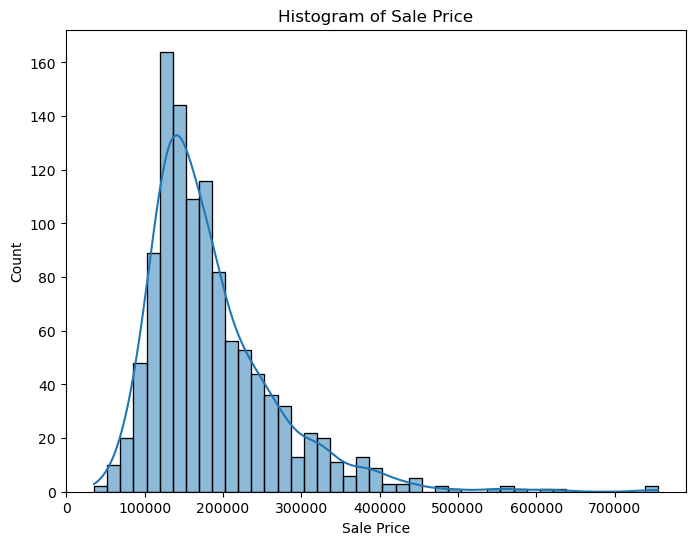

In [21]:
plt.figure(figsize = (8, 6))
sns.histplot(dfTrain['SalePrice'], kde = True, line_kws = {'color': 'red'})
plt.title("Histogram of Sale Price")
plt.xlabel("Sale Price")
plt.ylabel("Count")

### Removing sale price outliers

In [22]:
# Remove outliers of Rings
# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = dfTrain['SalePrice'].quantile(0.25)
Q3 = dfTrain['SalePrice'].quantile(0.75)

# Calculate the Interquartile Range (IQR)
IQR = Q3 - Q1

# Define the lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove outliers and create a new, clean DataFrame
dfTrain = dfTrain[(dfTrain['SalePrice'] >= lower_bound) & (dfTrain['SalePrice'] <= upper_bound)]

Text(0, 0.5, 'Count')

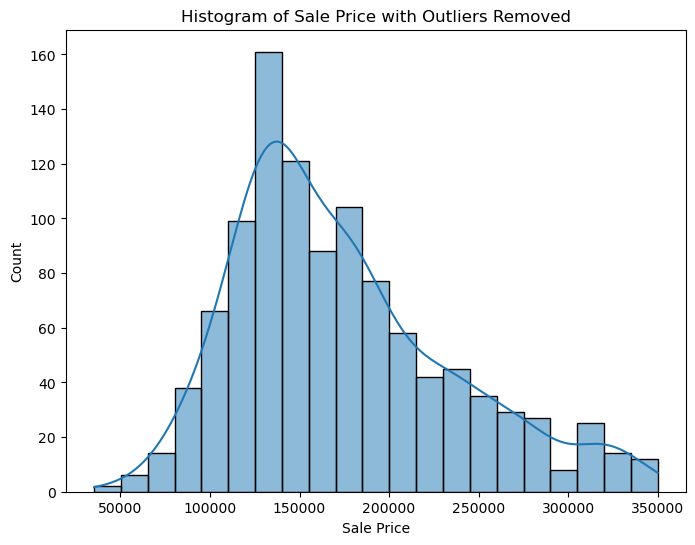

In [23]:
plt.figure(figsize = (8, 6))
sns.histplot(dfTrain['SalePrice'], kde = True, line_kws = {'color': 'red'})
plt.title("Histogram of Sale Price with Outliers Removed")
plt.xlabel("Sale Price")
plt.ylabel("Count")

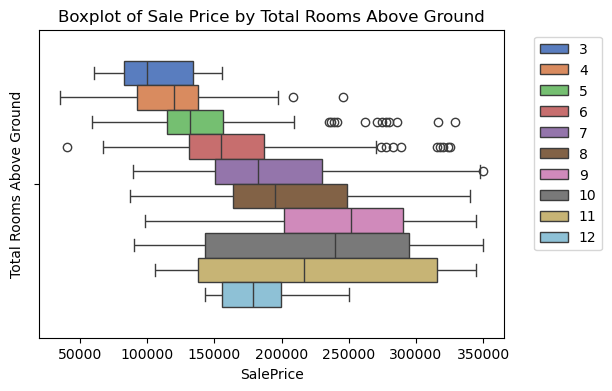

In [24]:
# Boxplot
plt.figure(figsize = (6,4))
sns.boxplot(x = 'SalePrice', data = dfTrain, hue = 'TotRmsAbvGrd', palette = 'muted')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Boxplot of Sale Price by Total Rooms Above Ground')
plt.ylabel('Total Rooms Above Ground')
plt.show()

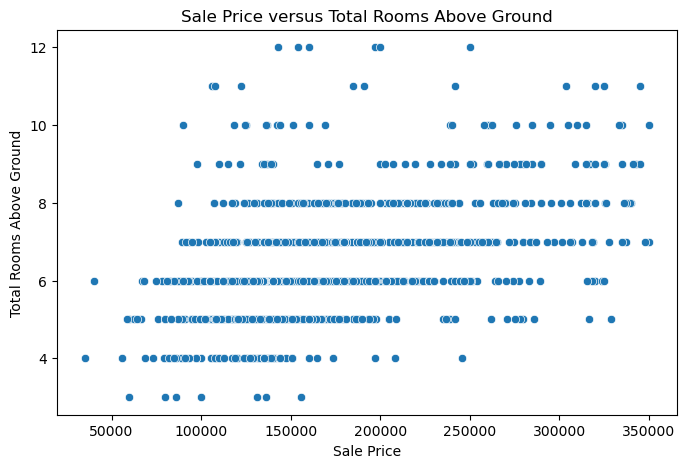

In [25]:
plt.figure(figsize = (8, 5))
sns.scatterplot(x = 'SalePrice', y = 'TotRmsAbvGrd', data = dfTrain, palette = 'Set1', legend = False)
plt.title("Sale Price versus Total Rooms Above Ground")
plt.xlabel("Sale Price")
plt.ylabel("Total Rooms Above Ground")
plt.show()

### Split data

In [26]:
X = dfTrain.drop(columns = ['SalePrice'])
y = dfTrain['SalePrice']
X_train, X_test, y_train, y_test = tts(X,
                                      y,
                                      train_size = 0.8,
                                      test_size = 0.2,
                                      shuffle = True,
                                      random_state = 27)

### Linear regression

In [27]:
feature_cols = dfTrain.columns 
model = LinearRegression()
model.fit(X, y)

# Print the intercept
print(f'Intercept: {model.intercept_}')

# Print the variables (feature names) and their coefficients
print('Coefficients:')
for feature, coef in zip(feature_cols, model.coef_):
    print(f'  {feature}:       {coef}')

Intercept: 362405.936135311
Coefficients:
  Id:       -2.551282603738577
  MSSubClass:       -143.0880665784203
  LotFrontage:       1.6507911700382092
  LotArea:       0.06795885644669544
  OverallQual:       15606.731474436197
  OverallCond:       4884.672806401741
  YearBuilt:       356.8568999718555
  YearRemodAdd:       213.05812604361049
  MasVnrArea:       6.085324949092244
  BsmtFinSF1:       4.102689595215093
  BsmtFinSF2:       0.9866616639054203
  BsmtUnfSF:       -0.15490837874589533
  TotalBsmtSF:       4.934442885347659
  1stFlrSF:       9.306337659127488
  2ndFlrSF:       12.424521976702383
  LowQualFinSF:       -3.6146056231439063
  GrLivArea:       18.116254011001654
  BsmtFullBath:       12031.662048552505
  BsmtHalfBath:       -1470.6285481087803
  FullBath:       7717.878468687728
  HalfBath:       479.52487654789945
  BedroomAbvGr:       -1804.0422979371813
  KitchenAbvGr:       -16447.696682436486
  TotRmsAbvGrd:       2286.7484505722387
  Fireplaces:       8057.5

In [28]:
# Add a constant (intercept) to the predictors
X = sm.add_constant(X) 

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.825
Model:                            OLS   Adj. R-squared:                  0.819
Method:                 Least Squares   F-statistic:                     139.0
Date:                Sat, 04 Apr 2026   Prob (F-statistic):               0.00
Time:                        13:29:54   Log-Likelihood:                -12390.
No. Observations:                1071   AIC:                         2.485e+04
Df Residuals:                    1035   BIC:                         2.503e+04
Df Model:                          35                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          3.624e+05   1.24e+06      0.293

In [29]:
lr = LinearRegression().fit(X_train, y_train)

print(f"Linear Regression-Training set score: {lr.score(X_train, y_train):.2f}")
print(f"Linear Regression-Test set score: {lr.score(X_test, y_test):.2f}")

Linear Regression-Training set score: 0.83
Linear Regression-Test set score: 0.77


In [30]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=0.7).fit(X_train, y_train)
print(f"Ridge Regression-Training set score: {ridge.score(X_train, y_train):.2f}")
print(f"Ridge Regression-Test set score: {ridge.score(X_test, y_test):.2f}")

Ridge Regression-Training set score: 0.83
Ridge Regression-Test set score: 0.77


### Polynomial regression

In [31]:
for i in range (1,4):
    model = Pipeline([('poly', PolynomialFeatures(degree=i)), 
                      ('linear', LinearRegression())])
    model.fit(X_train, y_train)

    score = cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error')

    print("Degree: %i  CV MSE: %.3f" % (i, np.mean(np.abs(score))))

Degree: 1  CV MSE: 834150296.932
Degree: 2  CV MSE: 84908876020.043
Degree: 3  CV MSE: 2234001739525.570


In [33]:
y_preds = model.predict(dfTest)

In [34]:
y_preds

array([ 7.35489701e+04, -4.71148277e+08,  2.24343171e+05, ...,
       -1.54266339e+05, -3.48461574e+05,  3.18005555e+05], shape=(1459,))

In [35]:
y_preds.shape

(1459,)

In [37]:
preds = y_preds
dfSub = pd.DataFrame()
dfSub['id'] = dfTest['Id']
dfSub['SalePrice'] = preds
dfSub

,id,SalePrice
0,1461,7.354897e+04
1,1462,-4.711483e+08
2,1463,2.243432e+05
3,1464,2.676329e+05
4,1465,1.423437e+05
...,...,...
1454,2915,-6.086446e+04
1455,2916,-3.749831e+04
1456,2917,-1.542663e+05
1457,2918,-3.484616e+05


In [38]:
dfSub.to_csv("submissionLinear.csv", index = False)

### Kaggle.com submission leaderboard

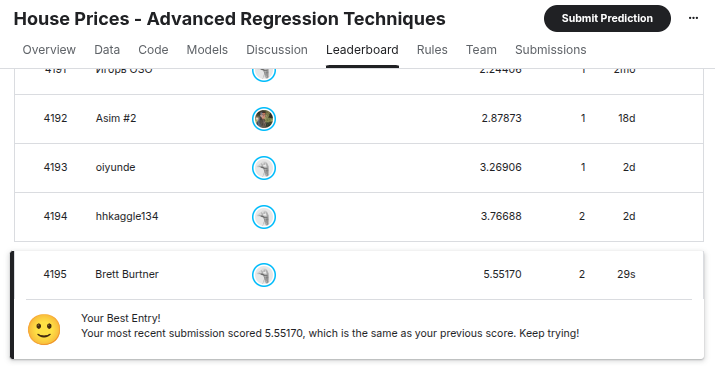

### Polynomial

In [39]:
polySalePrice = MS([poly('SalePrice', degree = 2)]).fit(dfTrain)
M = sm.OLS(y, polySalePrice.transform(dfTrain)).fit()
summarize(M)

,coef,std err,t,P>|t|
intercept,1.738000e+05,1.090000e-11,1.600000e+16,0.0
"poly(SalePrice, degree=2)[0]",1.999000e+06,3.550000e-10,5.630000e+15,0.0
"poly(SalePrice, degree=2)[1]",1.094000e-08,3.550000e-10,3.080600e+01,0.0


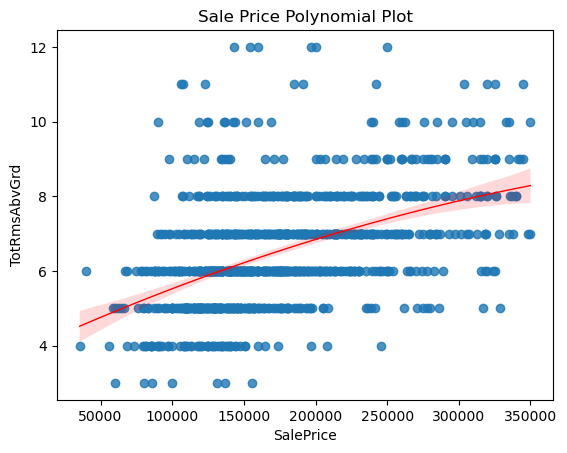

In [40]:
sns.regplot(data = dfTrain,
            x = 'SalePrice',
            y = 'TotRmsAbvGrd', order = 2,
           line_kws = {'linewidth': 1, 'color': 'red'})
plt.title('Sale Price Polynomial Plot')
plt.show()

In [41]:
dfTest

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
0,1461,20,80.0,11622,5,6,1961,1961,0.0,468.0,...,730.0,140,0,0,0,120,0,0,6,2010
1,1462,20,81.0,14267,6,6,1958,1958,108.0,923.0,...,312.0,393,36,0,0,0,0,12500,6,2010
2,1463,60,74.0,13830,5,5,1997,1998,0.0,791.0,...,482.0,212,34,0,0,0,0,0,3,2010
3,1464,60,78.0,9978,6,6,1998,1998,20.0,602.0,...,470.0,360,36,0,0,0,0,0,6,2010
4,1465,120,43.0,5005,8,5,1992,1992,0.0,263.0,...,506.0,0,82,0,0,144,0,0,1,2010
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,2915,160,21.0,1936,4,7,1970,1970,0.0,0.0,...,0.0,0,0,0,0,0,0,0,6,2006
1455,2916,160,21.0,1894,4,5,1970,1970,0.0,252.0,...,286.0,0,24,0,0,0,0,0,4,2006
1456,2917,20,160.0,20000,5,7,1960,1996,0.0,1224.0,...,576.0,474,0,0,0,0,0,0,9,2006
1457,2918,85,62.0,10441,5,5,1992,1992,0.0,337.0,...,0.0,80,32,0,0,0,0,700,7,2006


In [42]:
y_pred = model.predict(dfTest)

In [43]:
y_pred.shape

(1459,)

In [44]:
preds = y_pred
dfSub = pd.DataFrame()
dfSub['id'] = dfTest['Id']
dfSub['SalePrice'] = preds
dfSub

,id,SalePrice
0,1461,7.354897e+04
1,1462,-4.711483e+08
2,1463,2.243432e+05
3,1464,2.676329e+05
4,1465,1.423437e+05
...,...,...
1454,2915,-6.086446e+04
1455,2916,-3.749831e+04
1456,2917,-1.542663e+05
1457,2918,-3.484616e+05


### Create submission file

In [45]:
dfSub.to_csv("submissionPoly.csv", index = False)